# 02 — Ingénierie des variables

Les variables métier sont créées par `churn.features.FeatureEngineer`, un transformer scikit-learn
placé **dans le pipeline** : tout ce qui est appris (ici le tarif moyen par type de contrat) l'est
uniquement sur les plis d'entraînement de la validation croisée → aucune fuite.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn.config import FIGURES_DIR, SEED

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", "{:.4f}".format)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")


In [2]:
from churn.data import load, train_test
from churn.features import FeatureEngineer

X_train, X_test, y_train, y_test = train_test(load())
fe = FeatureEngineer().fit(X_train)
Xf = fe.transform(X_train)
new_cols = [c for c in Xf.columns if c not in X_train.columns]
Xf[new_cols].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
nb_services,5634.0000,NaN,NaN,NaN,4.1676,2.3209,1.0000,2.0000,4.0000,6.0000,9.0000
nb_addons,5634.0000,NaN,NaN,NaN,2.0580,1.8547,0.0000,0.0000,2.0000,3.0000,6.0000
avg_monthly_charge,5634.0000,NaN,NaN,NaN,64.9381,30.2249,13.8286,36.0455,70.5887,90.4644,121.4000
charge_increase,5634.0000,NaN,NaN,NaN,-0.0082,2.5986,-18.9000,-1.1764,0.0000,1.1333,19.1250
charge_vs_peers,5634.0000,NaN,NaN,NaN,-0.0000,30.0485,-47.7441,-30.0851,4.8542,24.5469,57.8802
tenure_bucket,5634,5,49m+,1789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_month_to_month,5634.0000,NaN,NaN,NaN,0.5506,0.4975,0.0000,0.0000,1.0000,1.0000,1.0000
auto_payment,5634.0000,NaN,NaN,NaN,0.4361,0.4959,0.0000,0.0000,0.0000,1.0000,1.0000
has_security_support,5634.0000,NaN,NaN,NaN,0.1573,0.3641,0.0000,0.0000,0.0000,0.0000,1.0000
fiber_no_support,5634.0000,NaN,NaN,NaN,0.3166,0.4652,0.0000,0.0000,0.0000,1.0000,1.0000


| Variable | Intuition métier |
|---|---|
| `nb_services`, `nb_addons` | un client équipé de nombreux services est plus « ancré » |
| `avg_monthly_charge` | `TotalCharges / tenure` : tarif moyen payé historiquement |
| `charge_increase` | facture actuelle − moyenne historique : une hausse récente pousse au départ |
| `charge_vs_peers` | facture vs moyenne des clients du même contrat (appris sur le train) |
| `tenure_bucket` | effets non linéaires de l'ancienneté (utile au modèle linéaire) |
| `is_month_to_month`, `auto_payment` | engagement et friction de paiement |
| `has_security_support`, `fiber_no_support` | interactions repérées en EDA |

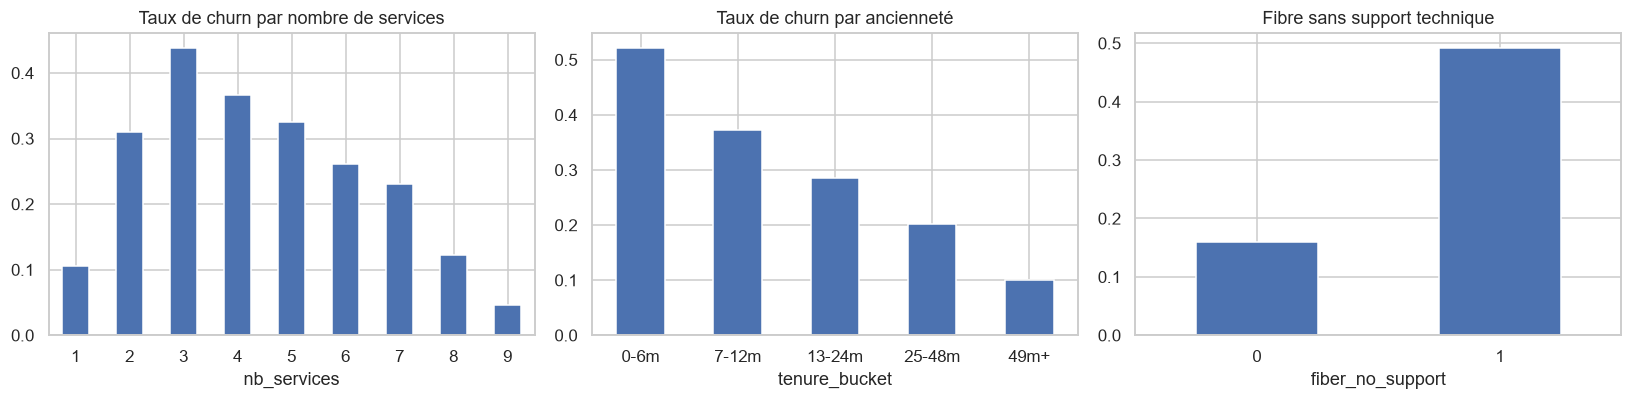

In [3]:
d = Xf.assign(Churn=y_train.values)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
d.groupby("nb_services")["Churn"].mean().plot.bar(ax=axes[0], rot=0, color="#4C72B0")
axes[0].set_title("Taux de churn par nombre de services")
order = ["0-6m", "7-12m", "13-24m", "25-48m", "49m+"]
d.groupby("tenure_bucket")["Churn"].mean().reindex(order).plot.bar(ax=axes[1], rot=0, color="#4C72B0")
axes[1].set_title("Taux de churn par ancienneté")
d.groupby("fiber_no_support")["Churn"].mean().plot.bar(ax=axes[2], rot=0, color="#4C72B0")
axes[2].set_title("Fibre sans support technique")
fig.tight_layout()
save(fig, "02_engineered_features")

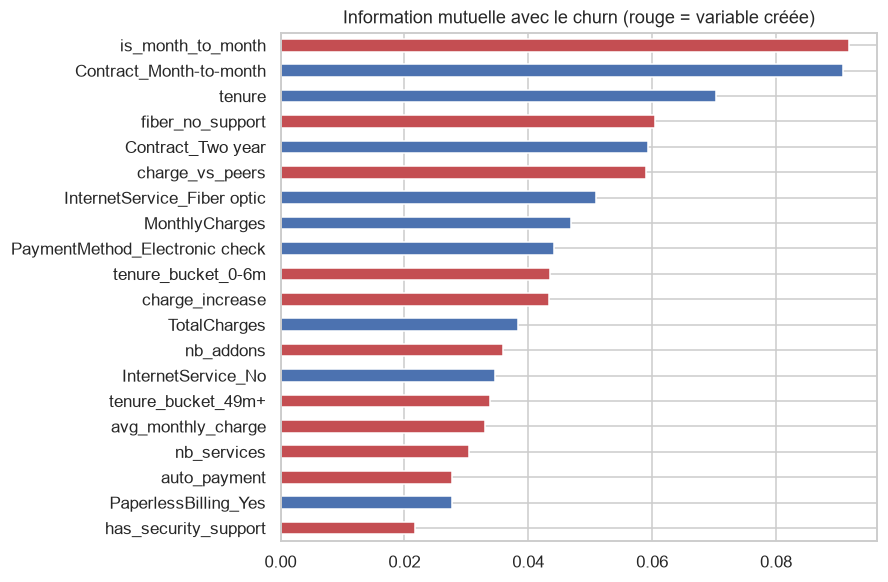

In [4]:
from sklearn.feature_selection import mutual_info_classif
from churn.features import make_preprocessor

Xt = make_preprocessor(scale=False).set_output(transform="pandas").fit_transform(Xf)
mi = pd.Series(mutual_info_classif(Xt, y_train, random_state=SEED), index=Xt.columns)
mi.index = mi.index.str.replace(r"^(num|cat)__", "", regex=True)
top = mi.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#C44E52" if any(top_name.startswith(c) for c in new_cols) else "#4C72B0" for top_name in top.index]
top[::-1].plot.barh(ax=ax, color=colors[::-1])
ax.set_title("Information mutuelle avec le churn (rouge = variable créée)")
save(fig, "02_mutual_information")

## Ablation : les nouvelles variables améliorent-elles vraiment le modèle ?

On compare, **sur les mêmes plis** de validation croisée, une régression logistique sur les
variables brutes et la même sur les variables enrichies, puis on teste la différence (Wilcoxon
apparié). 10 plis (5 × 2 répétitions) pour plus de puissance.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from churn.evaluate import paired_cv_test
from churn.models import build_pipeline

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)
raw_pipe = make_pipeline(make_preprocessor(), LogisticRegression(max_iter=2000))
scores_raw = cross_val_score(raw_pipe, X_train, y_train, cv=cv, scoring="average_precision")
scores_fe = cross_val_score(build_pipeline("logreg"), X_train, y_train, cv=cv, scoring="average_precision")

print(f"PR-AUC brutes    : {scores_raw.mean():.4f} ± {scores_raw.std():.4f}")
print(f"PR-AUC enrichies : {scores_fe.mean():.4f} ± {scores_fe.std():.4f}")
paired_cv_test(scores_fe, scores_raw)

PR-AUC brutes    : 0.6612 ± 0.0174
PR-AUC enrichies : 0.6634 ± 0.0155


{'mean_diff': 0.002183916737861791, 'p_value': 0.375}

**Résultat honnête** : le gain de PR-AUC est faible (+0,002) et **non significatif** (Wilcoxon
p ≈ 0,4). Sur ce dataset déjà très « propre », la régression logistique capte l'essentiel du
signal avec les variables brutes. Les variables créées sont conservées pour une autre raison :
**l'interprétabilité** des explications SHAP servies par l'API (« contrat mensuel », « fibre
sans support », « hausse de facture »), plus parlantes pour un conseiller qu'un one-hot brut.